# Predictive Maintenance - LSTM & Final Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import shap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f" PyTorch version: {torch.__version__}")
print(f" CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   Using CPU")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n Using device: {device}")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


 PyTorch version: 2.1.2+cpu
 CUDA available: False
   Using CPU

 Using device: cpu


### 1. Load Data

In [2]:
train_processed = pd.read_csv('../data/processed/train_processed.csv')

print("Data Loading")
print(f"\n Dataset shape: {train_processed.shape}")

feature_cols = [col for col in train_processed.columns if col not in ['unit_id', 'RUL']]
X = train_processed[feature_cols].values
y = train_processed['RUL'].values
unit_ids = train_processed['unit_id'].values

print(f" Number of features: {len(feature_cols)}")
print(f" Target variable: RUL")

Data Loading

 Dataset shape: (20631, 113)
 Number of features: 111
 Target variable: RUL


### 2. Prepare Sequence for LSTM

    Create sequences for LSTM.
    
    Args:
        X: Feature array
        y: Target array
        unit_ids: Engine IDs
        time_steps: Sequence length
    
    Returns:
        X_seq: Sequences of shape (n_sequences, time_steps, n_features)
        y_seq: Targets of shape (n_sequences,)
        engine_ids_seq: Engine IDs for each sequence

In [3]:
def create_sequences(X, y, unit_ids, time_steps=10):
    X_seq, y_seq, engine_ids_seq = [], [], []

    for engine_id in np.unique(unit_ids):
        engine_mask = unit_ids == engine_id
        X_engine = X[engine_mask]
        y_engine = y[engine_mask]

        for i in range(len(X_engine) - time_steps):
            X_seq.append(X_engine[i:(i + time_steps)])
            y_seq.append(y_engine[i + time_steps])
            engine_ids_seq.append(engine_id)
    
    return np.array(X_seq), np.array(y_seq), np.array(engine_ids_seq)

print("Creating Sequences For LSTM")

TIME_STEPS = 10
print(f"\n Sequence window size: {TIME_STEPS} time steps")
print("\n Creating sequences... ")

start_time = time.time()
X_seq, y_seq, engine_ids_seq = create_sequences(X, y, unit_ids, time_steps=TIME_STEPS)
creation_time = time.time() - start_time

print(f"\n Sequences created in {creation_time:.2f} seconds")
print(f"\n Sequence shapes:")
print(f"   - X_seq: {X_seq.shape} (n_sequences, time_steps, n_features)")
print(f"   - y_seq: {y_seq.shape} (n_sequences,)")
print(f"\n Explanation:")
print(f"   - We have {X_seq.shape[0]} sequences")
print(f"   - Each sequence has {X_seq.shape[1]} time steps")
print(f"   - Each time step has {X_seq.shape[2]} features")

Creating Sequences For LSTM

 Sequence window size: 10 time steps

 Creating sequences... 

 Sequences created in 0.20 seconds

 Sequence shapes:
   - X_seq: (19631, 10, 111) (n_sequences, time_steps, n_features)
   - y_seq: (19631,) (n_sequences,)

 Explanation:
   - We have 19631 sequences
   - Each sequence has 10 time steps
   - Each time step has 111 features


### 3. Train-Test Split for LSTM

In [4]:
unique_engines = np.unique(engine_ids_seq)
n_train_engines = int(len(unique_engines) * 0.8)

train_engines = unique_engines[:n_train_engines]
test_engines = unique_engines[n_train_engines:]

train_mask = np.isin(engine_ids_seq, train_engines)
test_mask = np.isin(engine_ids_seq, test_engines)

X_train = X_seq[train_mask]
X_test = X_seq[test_mask]
y_train = y_seq[train_mask]
y_test = y_seq[test_mask]

print("Train-Test Split")
print(f"\n Split complete:")
print(f"   - Training sequences: {len(X_train)}")
print(f"   - Testing sequences: {len(X_test)}")
print(f"   - Training engines: {len(train_engines)}")
print(f"   - Testing engines: {len(test_engines)}")

overlap = set(train_engines) & set(test_engines)
print(f"\n Data leakage check: {' PASSED' if not overlap else ' FAILED'}")

Train-Test Split

 Split complete:
   - Training sequences: 15338
   - Testing sequences: 4293
   - Training engines: 80
   - Testing engines: 20

 Data leakage check:  PASSED


In [5]:
X_train = np.asarray(X_train, dtype=np.float32)
X_test  = np.asarray(X_test, dtype=np.float32)

mask_train = np.isfinite(X_train).all(axis=(1, 2))
mask_test  = np.isfinite(X_test).all(axis=(1, 2))

X_train = X_train[mask_train]
y_train = y_train[mask_train]

X_test = X_test[mask_test]
y_test = y_test[mask_test]

print("\nAfter removing NaN sequences:")
print("X_train:", X_train.shape, "| removed:", (~mask_train).sum())
print("X_test :", X_test.shape,  "| removed:", (~mask_test).sum())

print("Any NaN in X_train?", np.isnan(X_train).any())
print("Any NaN in X_test?",  np.isnan(X_test).any())



After removing NaN sequences:
X_train: (15258, 10, 111) | removed: 80
X_test : (4273, 10, 111) | removed: 20
Any NaN in X_train? False
Any NaN in X_test? False


### 4. Crate PyTorch Datasets and DataLoaders

In [6]:
X_train = np.asarray(X_train, dtype=np.float32)
X_test  = np.asarray(X_test, dtype=np.float32)

y_train = np.asarray(y_train, dtype=np.float32)
y_test  = np.asarray(y_test, dtype=np.float32)

print(X_train.dtype, X_test.dtype)



float32 float32


In [7]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("Creating PyTorch DataLoaders")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n Batch size: {BATCH_SIZE}")
print(f" Training batches: {len(train_loader)}")
print(f" Testing batches: {len(test_loader)}")

example_batch_X, example_batch_y = next(iter(train_loader))
print(f"\n Example batch shapes:")
print(f"   - Input: {example_batch_X.shape} (batch_size, time_steps, features)")
print(f"   - Target: {example_batch_y.shape} (batch_size, 1)")


Creating PyTorch DataLoaders

 Batch size: 64
 Training batches: 239
 Testing batches: 67

 Example batch shapes:
   - Input: torch.Size([64, 10, 111]) (batch_size, time_steps, features)
   - Target: torch.Size([64, 1]) (batch_size, 1)


## 5. Define LSTM Model


In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc1 = nn.Linear(hidden_size, 16)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(16, 1)
    
    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)

        last_output = lstm_out[:, -1, :]

        out = self.fc1(last_output)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

input_size = X_train.shape[2]
model = LSTMModel(input_size=input_size, hidden_size=64, num_layers=2, dropout=0.2)
model = model.to(device)

print("LSTM Model Architecture")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Model Statistics:")
print(f"   - Total parameters: {total_params:,}")
print(f"   - Trainable parameters: {trainable_params:,}")
print(f"   - Input features: {input_size}")
print(f"   - Hidden size: 64")
print(f"   - Number of layers: 2")

LSTM Model Architecture
LSTMModel(
  (lstm): LSTM(111, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=64, out_features=16, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

 Model Statistics:
   - Total parameters: 79,649
   - Trainable parameters: 79,649
   - Input features: 111
   - Hidden size: 64
   - Number of layers: 2


## 6. Train LSTM Model

### Training Process:

```
FOR each epoch:
    FOR each batch:
        1. Forward pass: Get predictions
        2. Calculate loss: How wrong are we?
        3. Backward pass: Calculate gradients
        4. Update weights: Adjust parameters
    
    Evaluate on validation set
    Save if best model
```


**Loss Function**: MSE (Mean Squared Error)

**Optimizer**: Adam

**Learning Rate**: 0.001



In [9]:
import numpy as np
import torch

def check_tensor(name, arr):
    arr = np.asarray(arr)
    print(f"{name}: dtype={arr.dtype}, shape={arr.shape}")
    print("  NaN:", np.isnan(arr).any())
    print("  Inf:", np.isinf(arr).any())
    if np.isnan(arr).any() or np.isinf(arr).any():
        # show where
        idx = np.argwhere(~np.isfinite(arr))
        print("  First bad index:", idx[0])
        print("  Bad value:", arr[tuple(idx[0])])

check_tensor("X_train", X_train)
check_tensor("y_train", y_train)
check_tensor("X_test", X_test)
check_tensor("y_test", y_test)


X_train: dtype=float32, shape=(15258, 10, 111)
  NaN: False
  Inf: False
y_train: dtype=float32, shape=(15258,)
  NaN: False
  Inf: False
X_test: dtype=float32, shape=(4273, 10, 111)
  NaN: False
  Inf: False
y_test: dtype=float32, shape=(4273,)
  NaN: False
  Inf: False


In [10]:
NUM_EPOCHS = 50
LEARNING_RATE = 0.001

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

print("Training LSTM Model")
print(f"\n Training configuration:")
print(f"   - Epochs: {NUM_EPOCHS}")
print(f"   - Learning rate: {LEARNING_RATE}")
print(f"   - Batch size: {BATCH_SIZE}")
print(f"   - Loss function: MSE")
print(f"   - Optimizer: Adam")
print(f"\n Starting training...\n")

train_losses = []
test_losses = []

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()
        
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    test_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item()
    
    test_loss /= len(test_loader)
    test_losses.append(test_loss)

    scheduler.step(test_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] | "
              f"Train Loss: {train_loss:.4f} | "
              f"Test Loss: {test_loss:.4f} | "
              f"Test RMSE: {np.sqrt(test_loss):.2f}")

training_time = time.time() - start_time

print(f"\n Training complete!")
print(f" Total training time: {training_time:.2f} seconds ({training_time/60:.1f} minutes)")
print(f" Final training loss: {train_losses[-1]:.4f}")
print(f" Final test loss: {test_losses[-1]:.4f}")
print(f" Final test RMSE: {np.sqrt(test_losses[-1]):.2f} cycles")

Training LSTM Model

 Training configuration:
   - Epochs: 50
   - Learning rate: 0.001
   - Batch size: 64
   - Loss function: MSE
   - Optimizer: Adam

 Starting training...

Epoch [  5/50] | Train Loss: 357.9194 | Test Loss: 34.3524 | Test RMSE: 5.86
Epoch [ 10/50] | Train Loss: 353.6195 | Test Loss: 28.4635 | Test RMSE: 5.34
Epoch [ 15/50] | Train Loss: 289.1660 | Test Loss: 18.2905 | Test RMSE: 4.28
Epoch 00020: reducing learning rate of group 0 to 5.0000e-04.
Epoch [ 20/50] | Train Loss: 266.2969 | Test Loss: 18.9802 | Test RMSE: 4.36
Epoch [ 25/50] | Train Loss: 258.9040 | Test Loss: 12.4018 | Test RMSE: 3.52
Epoch [ 30/50] | Train Loss: 261.3360 | Test Loss: 22.3164 | Test RMSE: 4.72
Epoch 00031: reducing learning rate of group 0 to 2.5000e-04.
Epoch [ 35/50] | Train Loss: 251.3233 | Test Loss: 19.9549 | Test RMSE: 4.47
Epoch [ 40/50] | Train Loss: 253.9788 | Test Loss: 14.7953 | Test RMSE: 3.85
Epoch 00044: reducing learning rate of group 0 to 1.2500e-04.
Epoch [ 45/50] | Trai

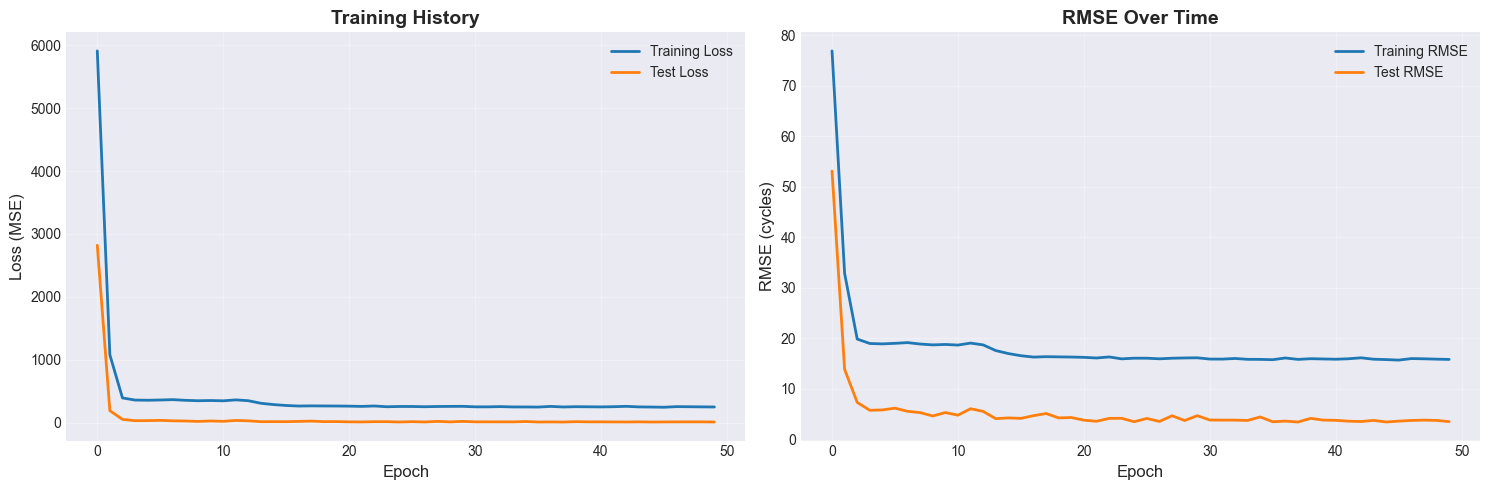


 What to look for:
   - Training and test loss should both decrease
   - If test loss increases while training decreases = overfitting
   - Curves should stabilize (flatten) near the end


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(train_losses, label='Training Loss', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Training History', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([np.sqrt(loss) for loss in train_losses], label='Training RMSE', linewidth=2)
axes[1].plot([np.sqrt(loss) for loss in test_losses], label='Test RMSE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('RMSE (cycles)', fontsize=12)
axes[1].set_title('RMSE Over Time', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n What to look for:")
print("   - Training and test loss should both decrease")
print("   - If test loss increases while training decreases = overfitting")
print("   - Curves should stabilize (flatten) near the end")

### 7. Evaluate LSTM Model

In [12]:
model.eval()
predictions = []

with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        predictions.extend(outputs.cpu().numpy())

y_pred_lstm = np.array(predictions).flatten()
y_test_np = y_test.flatten()

rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_lstm))
mae = mean_absolute_error(y_test_np, y_pred_lstm)
r2 = r2_score(y_test_np, y_pred_lstm)

errors = y_pred_lstm - y_test_np
late_predictions = errors < 0
early_predictions = errors > 0
late_penalty = np.sum(np.abs(errors[late_predictions]) * 2)
early_penalty = np.sum(np.abs(errors[early_predictions]))
asymmetric_score = (late_penalty + early_penalty) / len(y_test_np)
overestimated_late_pct = (late_predictions.sum() / len(y_test_np)) * 100

print("LSTM MODEL EVALUATION")

print(f"\n Standard Metrics:")
print(f"   - RMSE: {rmse:.2f} cycles")
print(f"   - MAE:  {mae:.2f} cycles")
print(f"   - R²:   {r2:.4f}")
print(f"\n Business Metrics:")
print(f"   - Asymmetric Score: {asymmetric_score:.2f}")
print(f"   - Late Predictions: {overestimated_late_pct:.1f}%")


LSTM MODEL EVALUATION

 Standard Metrics:
   - RMSE: 3.55 cycles
   - MAE:  3.12 cycles
   - R²:   0.9927

 Business Metrics:
   - Asymmetric Score: 5.77
   - Late Predictions: 78.9%


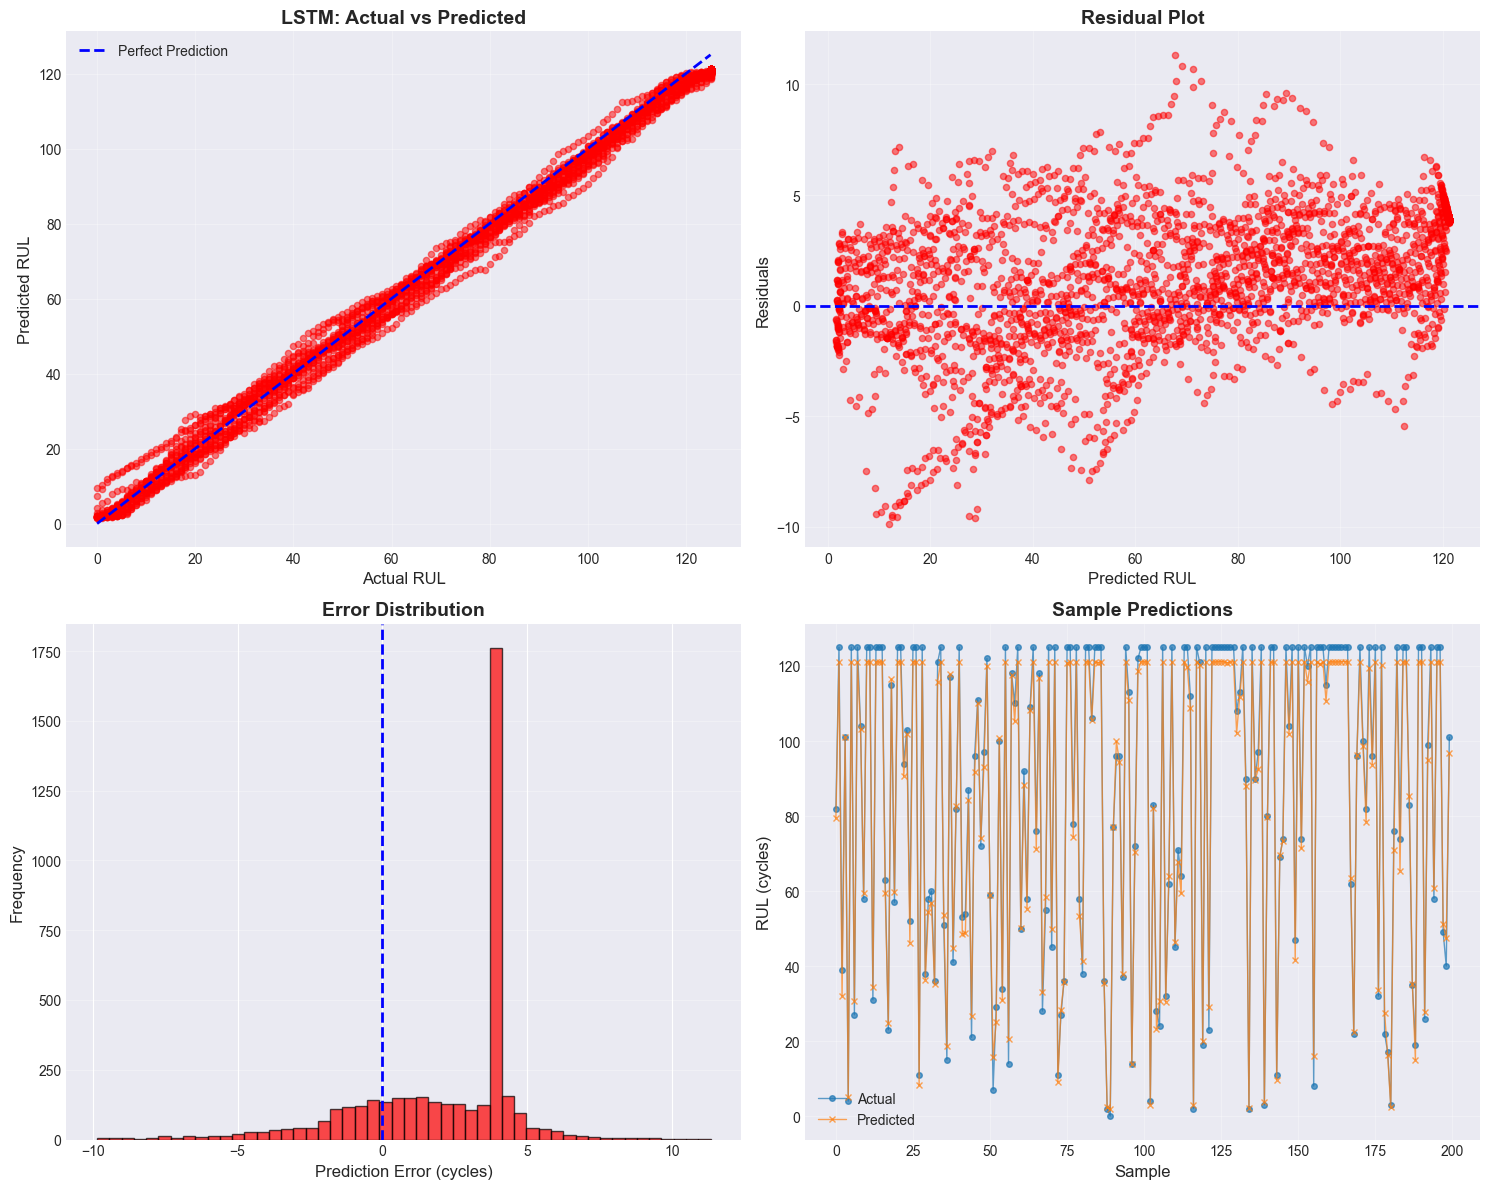

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].scatter(y_test_np, y_pred_lstm, alpha=0.5, s=20, c='red')
axes[0, 0].plot([y_test_np.min(), y_test_np.max()], 
                [y_test_np.min(), y_test_np.max()], 
                'b--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual RUL', fontsize=12)
axes[0, 0].set_ylabel('Predicted RUL', fontsize=12)
axes[0, 0].set_title('LSTM: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

residuals = y_test_np - y_pred_lstm
axes[0, 1].scatter(y_pred_lstm, residuals, alpha=0.5, s=20, c='red')
axes[0, 1].axhline(y=0, color='b', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted RUL', fontsize=12)
axes[0, 1].set_ylabel('Residuals', fontsize=12)
axes[0, 1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 0].axvline(x=0, color='b', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Prediction Error (cycles)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Error Distribution', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

sample_idx = np.random.choice(len(y_test_np), size=min(200, len(y_test_np)), replace=False)
axes[1, 1].plot(range(len(sample_idx)), y_test_np[sample_idx], 
                label='Actual', marker='o', markersize=4, linewidth=1, alpha=0.7)
axes[1, 1].plot(range(len(sample_idx)), y_pred_lstm[sample_idx], 
                label='Predicted', marker='x', markersize=4, linewidth=1, alpha=0.7)
axes[1, 1].set_xlabel('Sample', fontsize=12)
axes[1, 1].set_ylabel('RUL (cycles)', fontsize=12)
axes[1, 1].set_title('Sample Predictions', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8. Final Model Comparison

In [15]:
previous_results = pd.read_csv('../models/saved_models/model_comparison.csv')

lstm_results = {
    'model': 'LSTM',
    'rmse': rmse,
    'mae': mae,
    'r2': r2,
    'asymmetric_score': asymmetric_score,
    'overestimated_pct': overestimated_late_pct,
    'training_time': training_time
}

all_results = pd.concat([previous_results, pd.DataFrame([lstm_results])], ignore_index=True)

print("Final Model Comparison")
print()
display(all_results[['model', 'rmse', 'mae', 'r2', 'asymmetric_score', 
                     'overestimated_pct', 'training_time']])

best_rmse_idx = all_results['rmse'].idxmin()
best_model = all_results.loc[best_rmse_idx, 'model']

print(f"\n Overall Winner(by RMSE): {best_model}")
print(f"\n Ranking by RMSE:")
for idx, row in all_results.sort_values('rmse').iterrows():
    print(f"   {idx+1}. {row['model']:20s} RMSE: {row['rmse']:.2f}")

print(f"\n Model Selection Considerations:")
print(f"   - Best accuracy: {all_results.loc[best_rmse_idx, 'model']}")
print(f"   - Fastest training: {all_results.loc[all_results['training_time'].idxmin(), 'model']}")
print(f"   - Best for production: Consider trade-off between accuracy and complexity")

Final Model Comparison



,model,rmse,mae,r2,asymmetric_score,overestimated_pct,training_time
0,Linear Regression,6.810508,5.406918,0.972815,8.236885,57.701766,0.141631
1,Random Forest,5.708626,3.968453,0.980900,5.123918,27.967807,4.777269
2,XGBoost,0.928387,0.423754,0.999495,0.504796,36.999776,19.613116
3,LSTM,3.548115,3.120826,0.992703,5.770039,78.890709,148.524744



 Overall Winner(by RMSE): XGBoost

 Ranking by RMSE:
   3. XGBoost              RMSE: 0.93
   4. LSTM                 RMSE: 3.55
   2. Random Forest        RMSE: 5.71
   1. Linear Regression    RMSE: 6.81

 Model Selection Considerations:
   - Best accuracy: XGBoost
   - Fastest training: Linear Regression
   - Best for production: Consider trade-off between accuracy and complexity


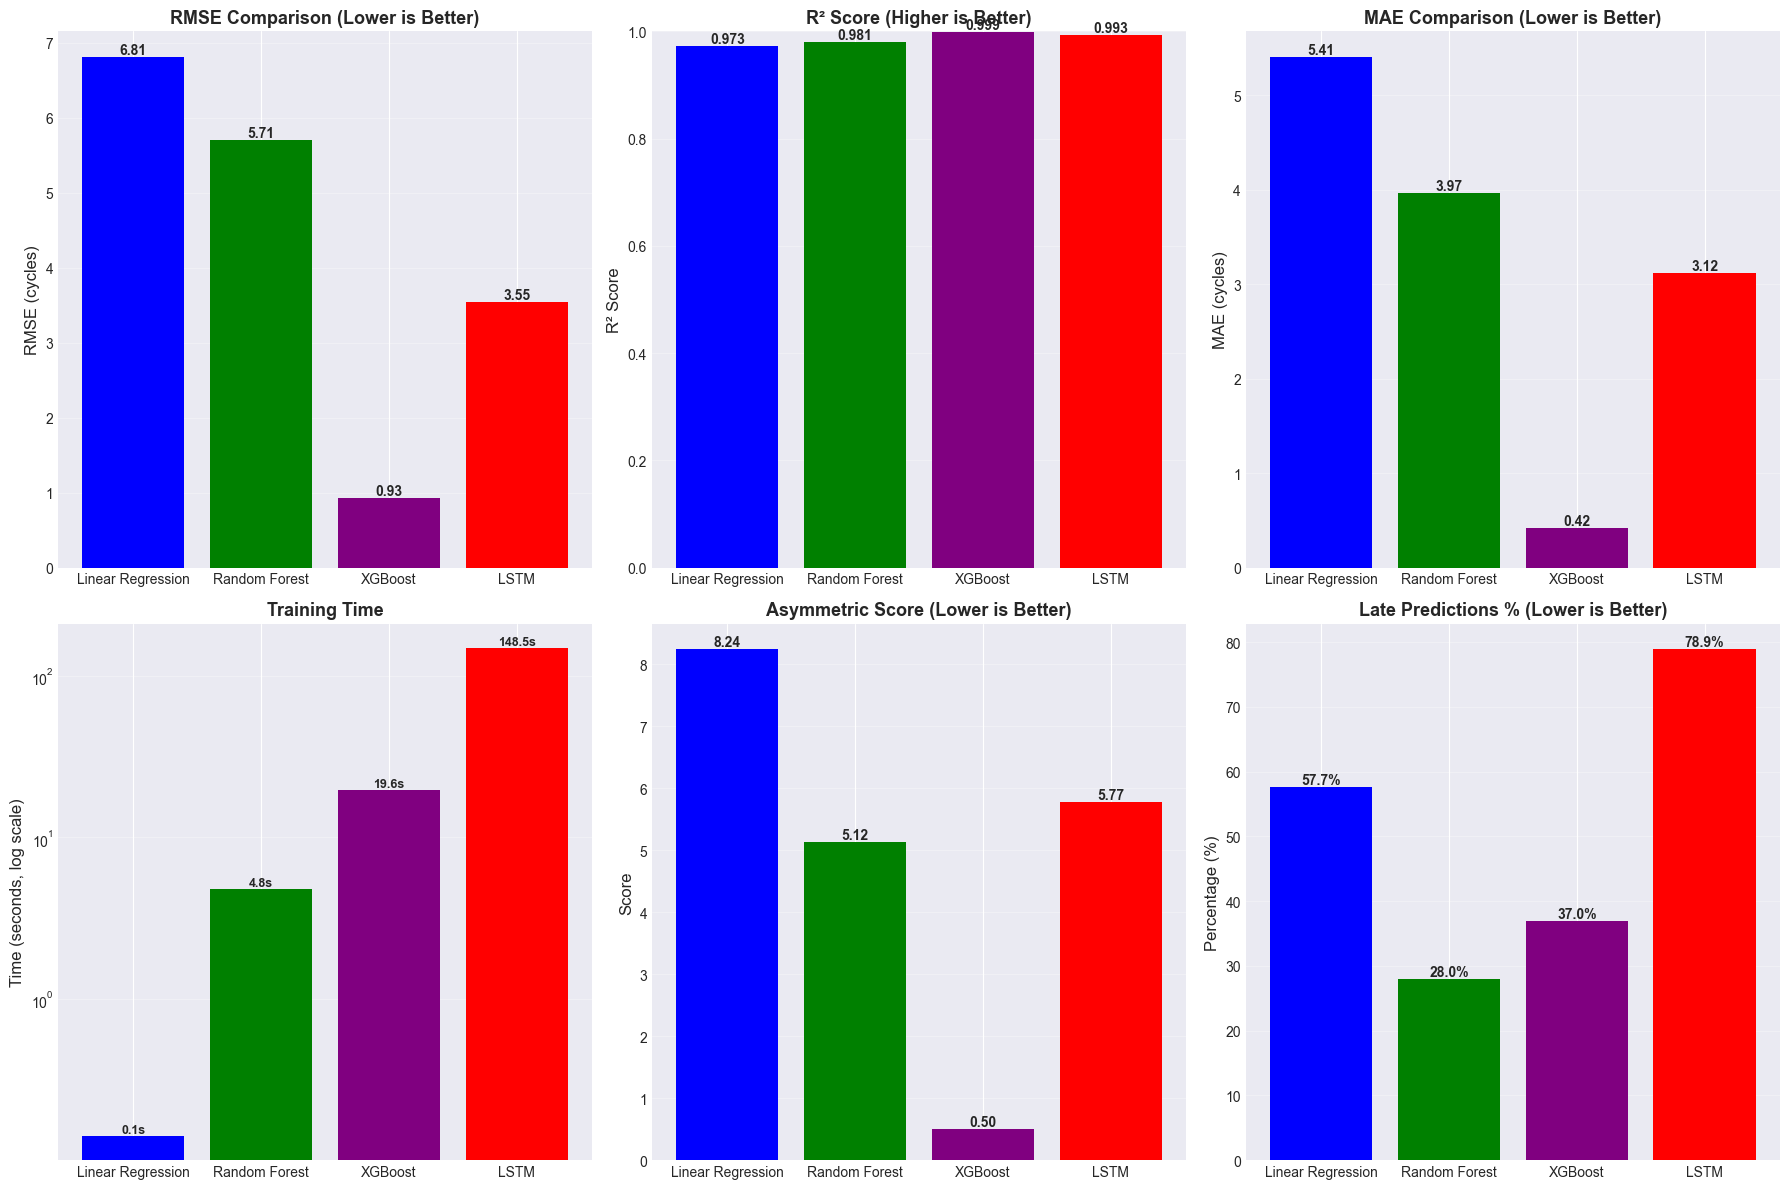

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

bars1 = axes[0, 0].bar(all_results['model'], all_results['rmse'], 
                       color=['blue', 'green', 'purple', 'red'])
axes[0, 0].set_ylabel('RMSE (cycles)', fontsize=12)
axes[0, 0].set_title('RMSE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars1):
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

bars2 = axes[0, 1].bar(all_results['model'], all_results['r2'],
                       color=['blue', 'green', 'purple', 'red'])
axes[0, 1].set_ylabel('R² Score', fontsize=12)
axes[0, 1].set_title('R² Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars2):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

bars3 = axes[0, 2].bar(all_results['model'], all_results['mae'],
                       color=['blue', 'green', 'purple', 'red'])
axes[0, 2].set_ylabel('MAE (cycles)', fontsize=12)
axes[0, 2].set_title('MAE Comparison (Lower is Better)', fontsize=13, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars3):
    height = bar.get_height()
    axes[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

bars4 = axes[1, 0].bar(all_results['model'], all_results['training_time'],
                       color=['blue', 'green', 'purple', 'red'])
axes[1, 0].set_ylabel('Time (seconds, log scale)', fontsize=12)
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Training Time', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars4):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=9)

bars5 = axes[1, 1].bar(all_results['model'], all_results['asymmetric_score'],
                       color=['blue', 'green', 'purple', 'red'])
axes[1, 1].set_ylabel('Score', fontsize=12)
axes[1, 1].set_title('Asymmetric Score (Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars5):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

bars6 = axes[1, 2].bar(all_results['model'], all_results['overestimated_pct'],
                       color=['blue', 'green', 'purple', 'red'])
axes[1, 2].set_ylabel('Percentage (%)', fontsize=12)
axes[1, 2].set_title('Late Predictions % (Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars6):
    height = bar.get_height()
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()